Import required Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Import Dataset through Kaggle API

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arshid/iris-flower-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'iris-flower-dataset' dataset.
Path to dataset files: /kaggle/input/iris-flower-dataset


In [ ]:
import os

Getting Dataset Path

In [ ]:
os.listdir(path)

['IRIS.csv']

In [ ]:
import os
df=pd.read_csv(os.path.join(path, 'IRIS.csv'))

In [ ]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


Finding Shape

In [ ]:
df.shape

(150, 5)

Finding Size

In [ ]:
df.size

750

Checking Datatypes

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


Checking Distribution

In [ ]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Checking Top Row sample

In [ ]:
df.head(1)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa


Checking Botttom Row Sample

In [ ]:
df.tail(1)

,sepal_length,sepal_width,petal_length,petal_width,species
149,5.9,3.0,5.1,1.8,Iris-virginica


Checking Duplicated values

In [ ]:
df.duplicated().sum()

np.int64(3)

Droping Duplicated Rows

In [ ]:
df=df.drop_duplicates().copy()

Checking Null Values

In [ ]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [ ]:
df['species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

For Encoding Non Numerical columns apply LabelEncoder

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoder=LabelEncoder()

In [ ]:
df['species']=encoder.fit_transform(df['species'])

Cheking Outliers Using Boxplot

<Axes: >

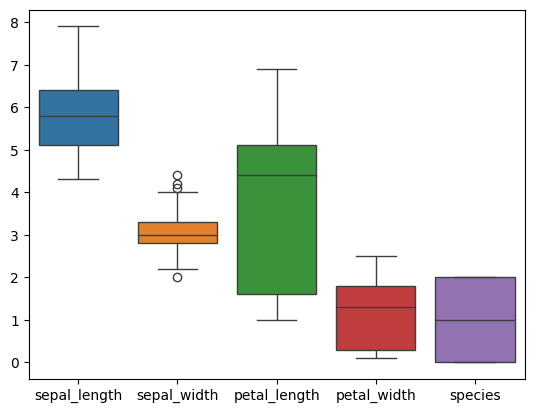

In [ ]:
sns.boxplot(df)

Checking Skewness in Sepal_width column using distribution Plot

/tmp/ipykernel_2971/3264937649.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['sepal_width'])


<Axes: xlabel='sepal_width', ylabel='Density'>

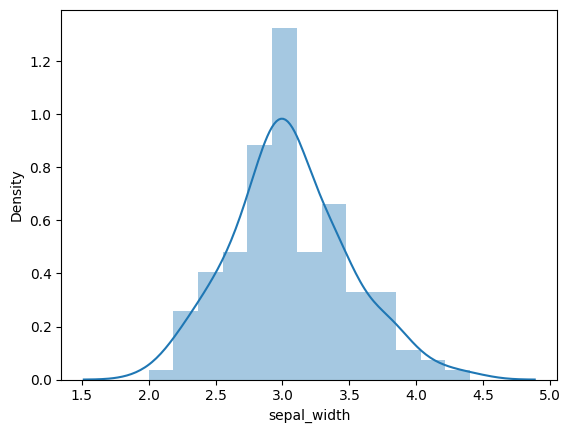

In [ ]:
sns.distplot(df['sepal_width'])

Relationships between all feature pairs using Pairplot

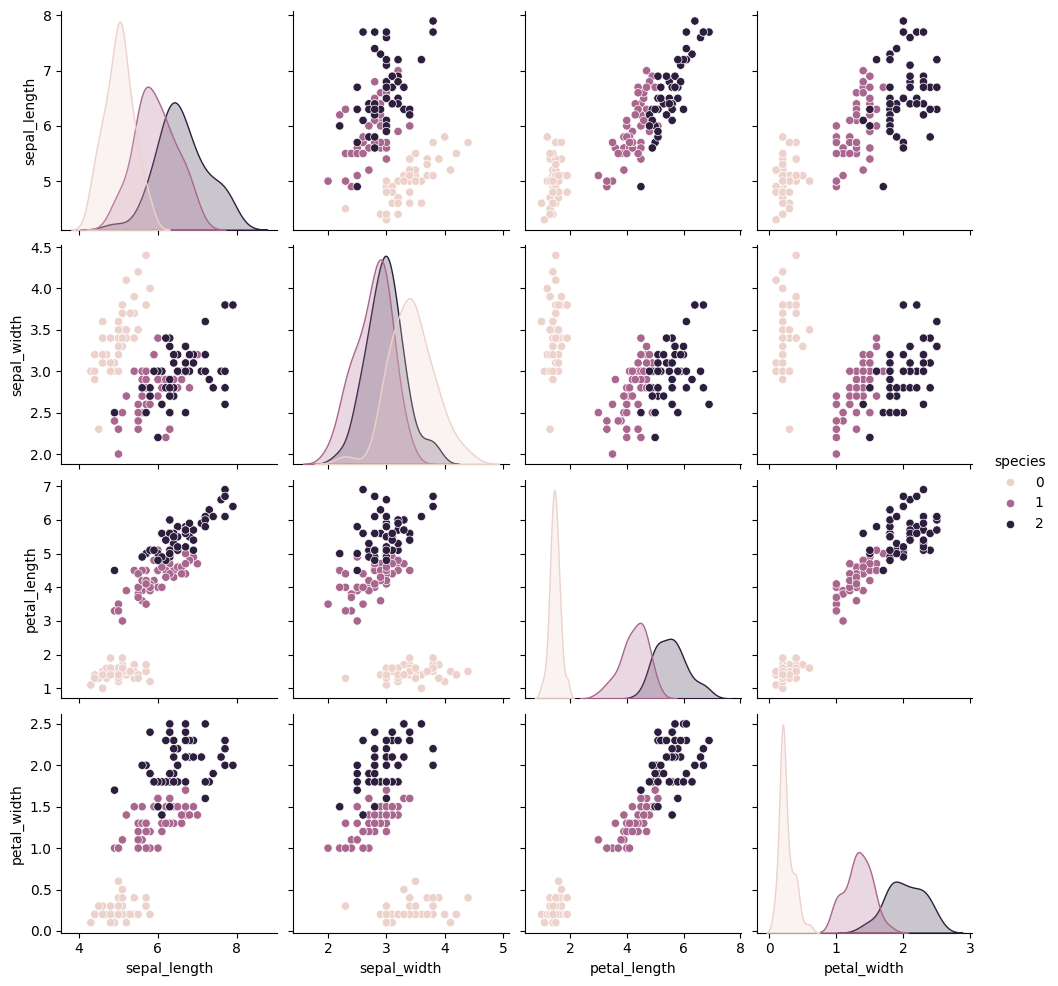

In [ ]:
sns.pairplot(df,hue='species')

Showing correlation using Heatmap

<Axes: >

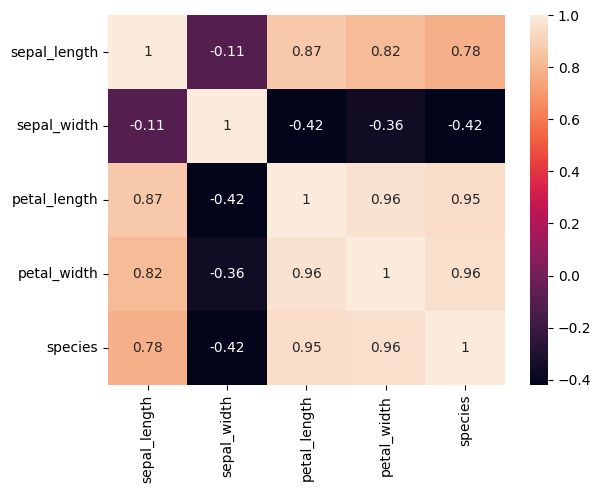

In [ ]:
sns.heatmap(df.corr(),annot=True)

Showing how species are Seperated using Scatterplot

<Axes: xlabel='petal_length', ylabel='petal_width'>

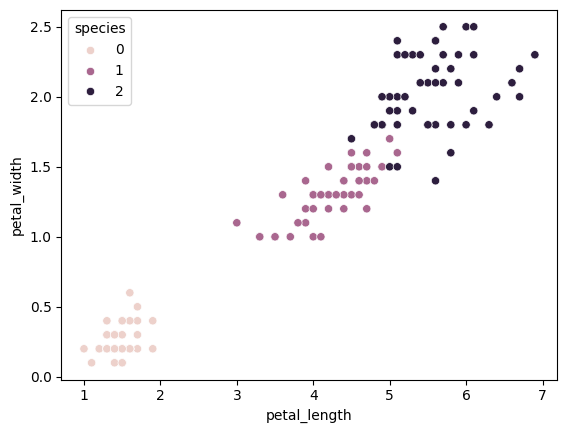

In [ ]:
sns.scatterplot(x='petal_length',y='petal_width',hue='species',data=df)

Feature Selection

In [ ]:
X=df.drop(columns=['species'],axis=1)
y=df['species']

Import Required Library for prediction

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler

Divide Data in 80% train and 20% Testing

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

Applying Logistic Regression Model

In [ ]:
model=LogisticRegression()

In [ ]:
model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
y_pred=model.predict(X_test)

Confusion Matrix

In [ ]:
print(confusion_matrix(y_test,y_pred))

[[11  0  0]
 [ 0  9  1]
 [ 0  1  8]]


Classification Report showing Accuracy

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.90      0.90      0.90        10
           2       0.89      0.89      0.89         9

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



Model Accuracy is 93%